---
title: "Bayesian Optimization with TabPFN Extensions"
description: "Use TabPFN as a Bayesian optimization surrogate via tabpfn-extensions and compare it against a BoTorch GP and random search on Michalewicz-2."
cookbookTags:
  - extensions
  - optimization
authors:
  - name: Klemens Flöge
    linkedin: https://www.linkedin.com/in/klemens-fl%C3%B6ge/
  - name: Tuana Çelik
    linkedin: https://www.linkedin.com/in/tuanacelik/
    twitter: https://x.com/tuanacelik
---

*Use TabPFN as the surrogate model inside a Bayesian optimization loop.*

This cookbook turns the `tabpfn-extensions` Bayesian optimization example into a step-by-step notebook. We optimize the 2D Michalewicz benchmark and compare TabPFN-driven search against two baselines under the same evaluation budget: BoTorch's Gaussian process with LogEI, the standard choice for this kind of problem, and random search. Along the way we show how `propose_next_point()` uses the predictive distribution from TabPFN to compute Expected Improvement (EI).

A single run tells you very little — the starting design alone can decide the outcome. So we repeat the whole experiment **5 times** with different initial designs and report the mean with a min–max band.

Relevant resources:

- [`tabpfn-extensions` repository](https://github.com/PriorLabs/tabpfn-extensions)
- [Bayesian optimization example script in `tabpfn-extensions`](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py)
- [`PFNs4BO` paper / reference implementation](https://github.com/automl/PFNs4BO)
- [TabPFN repo](https://github.com/PriorLabs/TabPFN)

## Setup

*Install the full TabPFN package plus the Bayesian optimization extras from `tabpfn-extensions`.*

This example uses the local PyTorch-backed TabPFN implementation, because the acquisition function reads TabPFN's predicted distribution directly. With `tabpfn>=9.0.0` the default model is TabPFN 3.5. The extras pull in BoTorch, which provides the GP baseline and the benchmark function.

In [ ]:
%pip install -q -U "tabpfn-extensions[bayesian_optimization]" "tabpfn>=9.0.0" matplotlib

*TabPFN as the surrogate, BoTorch for the GP baseline and the benchmark objective, and Matplotlib for the comparison plot.*

In [1]:
import warnings

# botorch triggers a torch.jit deprecation warning on import; it is harmless here.
warnings.filterwarnings("ignore", category=FutureWarning, message=r".*torch\.jit\.script.*")

import matplotlib.pyplot as plt
import numpy as np
import torch
from botorch.acquisition import LogExpectedImprovement
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.optim import optimize_acqf
from botorch.test_functions import Michalewicz
from gpytorch.mlls import ExactMarginalLogLikelihood

from tabpfn import TabPFNRegressor
from tabpfn_extensions.bayesian_optimization import propose_next_point

## The Optimization Problem

Michalewicz-2 is a two-dimensional benchmark with steep, narrow valleys separated by flat plateaus on `[0, π]^2`. After negation its optimum is `1.8013` at about `(2.20, 1.57)`. The plateaus carry almost no signal, so a stationary GP kernel has little to go on early, and random search rarely lands in the right valley.

The TabPFN surrogate predicts a **full bar distribution** over the objective value. `propose_next_point()` computes Expected Improvement exactly on that distribution — no Gaussian assumption — for a large batch of random candidates, then refines the most promising ones by sampling around them with a shrinking Gaussian. That optimizer is gradient-free, so it needs nothing special from the regressor.

Two details worth calling out:

- `negate=True` turns the minimization benchmark into a maximization problem, which is what EI expects; `optimal_value` follows the sign.
- The optimizer searches the unit cube `[0, 1]^2`, but Michalewicz lives on `[0, π]^2`, so every candidate is mapped onto the problem's own bounds before evaluation.

In [2]:
N_INIT = 10  # scrambled-Sobol points that every method starts from
N_BO_STEPS = 40  # one objective evaluation per step
N_SEEDS = 5  # independent repeats, each with its own initial design
N_ESTIMATORS = 8  # TabPFN ensemble size
GAP_FLOOR = 1e-4  # the log axis needs a positive floor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# EI maximizes the objective, so we negate Michalewicz to turn its optimum into a maximum.
objective = Michalewicz(dim=2, negate=True).to(DEVICE)
LO, HI = objective.bounds[0], objective.bounds[1]
print(f"Objective optimum: {objective.optimal_value:.4f} on {LO.tolist()}..{HI.tolist()}")


def evaluate(unit_x: torch.Tensor) -> torch.Tensor:
    """Evaluate the benchmark on points given in the unit cube."""
    return objective(LO + unit_x * (HI - LO))

Device: cpu
Objective optimum: 1.8013 on [0.0, 0.0]..[3.141592653589793, 3.141592653589793]


## Build the TabPFN Surrogate

*An ordinary `TabPFNRegressor` is all it takes.*

Nothing in the loop needs gradients with respect to the inputs, so we use the plain regressor with its full ensemble of 8 estimators. Those are the settings we validated on the continuous BoTorch benchmark suite (eight synthetic functions, 32 seeds, 250 evaluations each): an 8-estimator TabPFN with exact EI and this sampled optimizer had the best mean rank against BoTorch's GP with EI and LogEI at 250 evaluations, while the GP led on the smooth single-basin functions (Branin, Hartmann-3, Rosenbrock-like valleys) early on. Michalewicz is one of the multimodal functions where TabPFN was clearly ahead, by about 7× in mean regret at 50 evaluations, so it is where the difference shows within a notebook-sized budget.

Each repeat gets its own surrogate, seeded with that repeat's index, so the runs are independent. Keep TabPFN on `cpu` or `cuda`; Apple's `mps` backend is an order of magnitude slower here.

In [3]:
def make_surrogate(seed: int) -> TabPFNRegressor:
    return TabPFNRegressor(n_estimators=N_ESTIMATORS, device=DEVICE, random_state=seed)

## Run Bayesian Optimization

*Seed with a Sobol design, then let each method propose the next evaluation point.*

Each TabPFN iteration fits the surrogate on all observed evaluations so far, scores 2048 random candidates with Expected Improvement in one forward pass, and refines the top 16 by sampling around them for three rounds before returning the next point to evaluate. The GP baseline is BoTorch's `SingleTaskGP` with LogEI, maximized with `optimize_acqf`, in the configuration of Ament et al. (NeurIPS 2023).

We run that loop `N_SEEDS = 5` times. Within a repeat, all three methods start from the **same** `N_INIT` scrambled-Sobol evaluations, so the curves can only diverge once the acquisition strategy takes over. A Sobol sequence is a quasi-random design that covers the search space more evenly than uniform random points; scrambling randomizes it, so each repeat gets a different but still well-spread start. On CPU the TabPFN loop takes a few minutes per repeat; on a GPU it is much faster.

In [4]:
def run_tabpfn(init_x: torch.Tensor, init_y: torch.Tensor, seed: int) -> torch.Tensor:
    """Run the TabPFN-EI loop from a fixed init and return every observed y."""
    reg = make_surrogate(seed)
    train_x, train_y = init_x.clone(), init_y.clone()
    for _ in range(N_BO_STEPS):
        next_x = propose_next_point(reg, train_x, train_y)
        train_x = torch.cat([train_x, next_x.unsqueeze(0)])
        train_y = torch.cat([train_y, evaluate(next_x.unsqueeze(0))])
    return train_y


def run_gp_logei(init_x: torch.Tensor, init_y: torch.Tensor) -> torch.Tensor:
    """BoTorch's GP with LogEI: refit the GP each round, maximize LogEI with L-BFGS-B."""
    dim = init_x.shape[1]
    unit_bounds = torch.stack(
        [torch.zeros(dim, dtype=torch.double), torch.ones(dim, dtype=torch.double)]
    )
    train_x = init_x.double().cpu()
    train_y = init_y.double().cpu().unsqueeze(-1)
    for _ in range(N_BO_STEPS):
        gp = SingleTaskGP(  # Matern-5/2 ARD kernel by default
            train_x,
            train_y,
            input_transform=Normalize(d=dim),
            outcome_transform=Standardize(m=1),
        )
        fit_gpytorch_mll(ExactMarginalLogLikelihood(gp.likelihood, gp))
        acqf = LogExpectedImprovement(gp, best_f=train_y.max())
        next_x, _ = optimize_acqf(
            acqf, bounds=unit_bounds, q=1, num_restarts=16, raw_samples=512
        )
        next_y = evaluate(next_x.to(DEVICE).float()).double().cpu().unsqueeze(-1)
        train_x = torch.cat([train_x, next_x])
        train_y = torch.cat([train_y, next_y])
    return train_y.squeeze(-1).float().to(DEVICE)


def run_random(init_x: torch.Tensor, init_y: torch.Tensor) -> torch.Tensor:
    extra = torch.rand(N_BO_STEPS, init_x.shape[1], device=DEVICE)
    return torch.cat([init_y, evaluate(extra)])


def gap_to_optimum(y: torch.Tensor) -> np.ndarray:
    """Best-so-far distance to the known optimum — lower is better."""
    best = np.maximum.accumulate(y.detach().cpu().numpy())
    return np.maximum(objective.optimal_value - best, GAP_FLOOR)


RUNNERS = {
    "TabPFN-EI": lambda x, y, seed: run_tabpfn(x, y, seed),
    "GP-LogEI (BoTorch)": lambda x, y, seed: run_gp_logei(x, y),
    "Random search": lambda x, y, seed: run_random(x, y),
}
gaps = {name: [] for name in RUNNERS}

for seed in range(N_SEEDS):
    # One shared scrambled-Sobol init per repeat: every method sees the same start.
    sobol = torch.quasirandom.SobolEngine(objective.dim, scramble=True, seed=seed)
    init_x = sobol.draw(N_INIT).to(DEVICE)
    init_y = evaluate(init_x)

    for name, runner in RUNNERS.items():
        torch.manual_seed(1000 + seed)
        gaps[name].append(gap_to_optimum(runner(init_x, init_y, seed)))

    print(
        f"repeat {seed}: "
        + " | ".join(f"{name} gap {gaps[name][-1][-1]:9.4g}" for name in RUNNERS)
    )

gaps = {name: np.array(runs) for name, runs in gaps.items()}  # (N_SEEDS, N_INIT + N_BO_STEPS)

repeat 0: TabPFN-EI gap   0.02054 | GP-LogEI (BoTorch) gap    0.9174 | Random search gap    0.6139
repeat 1: TabPFN-EI gap    0.0001 | GP-LogEI (BoTorch) gap    0.4345 | Random search gap    0.8131
repeat 2: TabPFN-EI gap 0.0004174 | GP-LogEI (BoTorch) gap   0.01936 | Random search gap      0.37
repeat 3: TabPFN-EI gap    0.0001 | GP-LogEI (BoTorch) gap    0.6038 | Random search gap    0.7984
repeat 4: TabPFN-EI gap  0.001125 | GP-LogEI (BoTorch) gap    0.1895 | Random search gap    0.8819


## Compare the Three Methods

*Same objective, same budget, same starting points — only the choice of the next point differs.*

We report the **gap to the optimum** (`optimum - best so far`, the simple regret) on a log axis rather than the raw objective. Lower is better.

In [5]:
for name, runs in gaps.items():
    final = runs[:, -1]
    print(
        f"{name:<20} final gap over {N_SEEDS} repeats: "
        f"mean {final.mean():9.4g} | median {np.median(final):9.4g} | best {final.min():9.4g}"
    )

TabPFN-EI            final gap over 5 repeats: mean  0.004456 | median 0.0004174 | best    0.0001
GP-LogEI (BoTorch)   final gap over 5 repeats: mean    0.4329 | median    0.4345 | best   0.01936
Random search        final gap over 5 repeats: mean    0.6954 | median    0.7984 | best      0.37


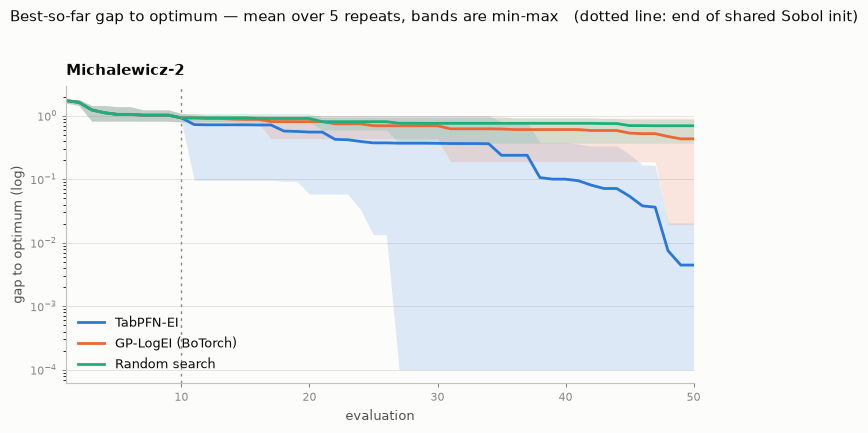

In [6]:
evals = np.arange(1, N_INIT + N_BO_STEPS + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.set_yscale("log")

# Mean over repeats, band spans min-max across them.
for name, color in [
    ("TabPFN-EI", "#2a78d6"),
    ("GP-LogEI (BoTorch)", "#eb6834"),
    ("Random search", "#1baf7a"),
]:
    runs = gaps[name]
    ax.fill_between(evals, runs.min(0), runs.max(0), color=color, alpha=0.15, lw=0)
    ax.plot(evals, runs.mean(0), color=color, lw=2, label=name)
ax.axvline(N_INIT, color="#898781", lw=1, ls=(0, (2, 3)))

ax.set_title("Michalewicz-2", fontsize=11, color="#0b0b0b", loc="left", fontweight="bold", pad=8)
ax.grid(visible=True, axis="y", color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelsize=8, length=3)
ax.set_xlim(1, N_INIT + N_BO_STEPS)
ax.set_xlabel("evaluation", fontsize=9, color="#52514e")
ax.set_ylabel("gap to optimum (log)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=9.5, labelcolor="#0b0b0b")

fig.suptitle(
    f"Best-so-far gap to optimum — mean over {N_SEEDS} repeats, bands are min-max"
    "   (dotted line: end of shared Sobol init)",
    fontsize=11,
    color="#0b0b0b",
    x=0.02,
    ha="left",
    y=1.02,
)
fig.tight_layout()
plt.show()

## Takeaways

- `tabpfn-extensions` provides the Bayesian optimization loop primitive, `propose_next_point()`, and it works with a plain `TabPFNRegressor`: exact EI on TabPFN's predicted distribution, maximized by a gradient-free sampled optimizer.
- On Michalewicz-2 with 50 evaluations, TabPFN-EI ends with a mean gap of 0.0045 (median 0.0004), against 0.43 for GP-LogEI and 0.70 for random search. TabPFN is ahead of the GP on every repeat, by at least a factor of 40.
- The picture is function-dependent. In our larger benchmark the GP is ahead early on smooth single-basin functions such as Branin and Hartmann-3 and wins on final precision there; TabPFN leads on multimodal functions like this one and Ackley, and overall from about 100 evaluations on, once its context has grown. Use more evaluations and more repeats for a clean comparison on your own problem.
- For more background, start with the upstream [example](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py) and the [`tabpfn-extensions` repo](https://github.com/PriorLabs/tabpfn-extensions).